# Banks Liquidity Analysis Project


Simple bank liquidity analysis using yfinance data

Set up libraries


In [280]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

pd.set_option('display.float_format', '{:,.0f}'.format)

import warnings
warnings.filterwarnings("ignore")

#### POBIERANIE DANYCH


In [281]:
# Bank  PEO.WA
Ticker = "MSFT"
Okres = "5y"

In [282]:
print("Pobieranie danych z Yahoo Finance...")
bank = yf.Ticker(Ticker)

print(bank)

Pobieranie danych z Yahoo Finance...
yfinance.Ticker object <MSFT>


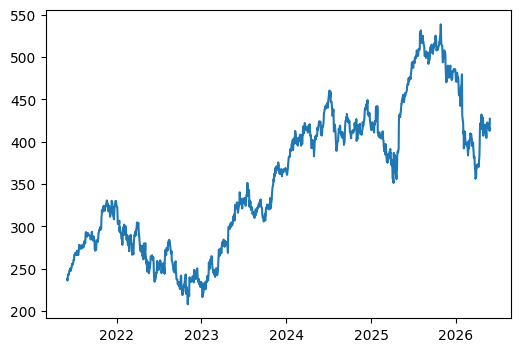

In [283]:
hist = bank.history(period=Okres)
if hist.empty:
    raise ValueError(f"Brak danych dla tickera: {Ticker}")
plt.figure(figsize=(6,4))
plt.plot(hist.index, hist["Close"])
plt.show()

In [284]:
balance_sheet  = bank.balance_sheet         
income_stmt    = bank.income_stmt
cashflow       = bank.cashflow
info           = bank.info

print(balance_sheet.head())

                            2025-06-30      2024-06-30      2023-06-30  \
Ordinary Shares Number   7,434,158,655   7,434,138,859   7,432,000,000   
Share Issued             7,434,158,655   7,434,138,859   7,432,000,000   
Net Debt                12,909,000,000  33,315,000,000  12,533,000,000   
Total Debt              60,588,000,000  67,127,000,000  59,965,000,000   
Tangible Book Value    201,366,000,000 121,660,000,000 128,971,000,000   

                           2022-06-30  2021-06-30  
Ordinary Shares Number  7,464,000,000         NaN  
Share Issued            7,464,000,000         NaN  
Net Debt               35,850,000,000         NaN  
Total Debt             61,270,000,000         NaN  
Tangible Book Value    87,720,000,000         NaN  


#### Quick Summary

In [285]:
print(f"  Company : {info.get('longName', Ticker)}")
print(f"  Sector : {info.get('sector', 'N/A')}")
print(f"  Currency : {info.get('currency', 'N/A')}")
print(f"  Data   : {hist.index[0].date()} → {hist.index[-1].date()}")
print(f"  Sample Size : {len(hist)} dni\n")

  Company : Microsoft Corporation
  Sector : Technology
  Currency : USD
  Data   : 2021-06-01 → 2026-05-28
  Sample Size : 1254 dni



#### Balance Sheet Analysis


In [286]:
def download_row(df, possible_names):
    for name in possible_names:
        if name in df.index:
            return df.loc[name]
    return None

In [287]:
current_assets = download_row(balance_sheet, ["Current Assets", "TotalCurrentAssets"])
current_liabilities = download_row(balance_sheet, ["Current Liabilities", "TotalCurrentLiabilities"])
cash = download_row(balance_sheet, ["Cash And Cash Equivalents", "Cash", "CashAndCashEquivalents"])
shortterm_loans = download_row(balance_sheet, ["Short Term Investments", "ShortTermInvestments"])
total_deposits = download_row(balance_sheet, ["Total Deposits", "Deposits"])
net_loans = download_row(balance_sheet, ["Net Loan", "NetLoans", "GrossLoans"])
total_assets = download_row(balance_sheet, ["Total Assets", "TotalAssets"])
stockholders_equity = download_row(balance_sheet, ["Stockholders Equity", "TotalEquityGrossMinorityInterest"])

operating_cashflow = download_row(cashflow, ["Operating Cash Flow", "Net Cash From Operating Activities"])

print(operating_cashflow)

2025-06-30   136,162,000,000
2024-06-30   118,548,000,000
2023-06-30    87,582,000,000
2022-06-30    89,035,000,000
2021-06-30               NaN
Name: Operating Cash Flow, dtype: float64


In [288]:
metrics = {}

dates = balance_sheet.columns

def print_row(name, series):
    if series is not None:
        values = "  ".join([f"{v/1e9:>8.2f}B" if not np.isnan(v) else "     N/A "for v in series])
        print(f"{name:<35} {values}")
    else:
        print(f"{name:<35} {'No data':>10}")

## METRIC !!!

In [289]:
print(f"{'Metric':<35} " + "  ".join([str(d.year) for d in dates]))
print("-" * 75)

print_row("Cash and Cash Equivalents [bn]", cash)
print_row("Current Assets [bn]", current_assets)
print_row("Current Liabilities [bn]", current_liabilities)
print_row("Customer Deposits [bn]", total_deposits)
print_row("Net Loans [bn]", net_loans)
print_row("Total Assets [bn]", total_assets)
print_row("Operating Cash Flow [bn]", operating_cashflow)

#all vibe coded btw

Metric                              2025  2024  2023  2022  2021
---------------------------------------------------------------------------
Cash and Cash Equivalents [bn]         30.24B     18.32B     34.70B     13.93B       N/A 
Current Assets [bn]                   191.13B    159.73B    184.26B    169.68B       N/A 
Current Liabilities [bn]              141.22B    125.29B    104.15B     95.08B       N/A 
Customer Deposits [bn]                 No data
Net Loans [bn]                         No data
Total Assets [bn]                     619.00B    512.16B    411.98B    364.84B       N/A 
Operating Cash Flow [bn]              136.16B    118.55B     87.58B     89.03B       N/A 


### Calculating Indicators

so many if else in case there are missing values

In [290]:
results = []

for data in dates:

    ca = float(current_assets[data]) if current_assets is not None else np.nan
    cl = float(current_liabilities[data]) if current_liabilities is not None else np.nan
    cas = float(cash[data]) if cash is not None else np.nan
    dep = float(total_deposits[data]) if total_deposits is not None else np.nan
    loan = float(net_loans[data]) if net_loans is not None else np.nan
    ta = float(total_assets[data]) if total_assets is not None else np.nan
    eq = float(stockholders_equity[data]) if stockholders_equity is not None else np.nan
    ocf = float(operating_cashflow[data]) if operating_cashflow is not None else np.nan

    current_ratio = ca / cl if not np.isnan(ca) and not np.isnan(cl) and cl != 0 else np.nan
    quick_ratio = cas / cl if not np.isnan(cas) and not np.isnan(cl) and cl != 0 else np.nan
    loan_to_deposit_ratio = loan / dep if not np.isnan(loan) and not np.isnan(dep) and dep != 0 else np.nan
    leverage_assets_equity = ta / eq if not np.isnan(ta) and not np.isnan(eq) and eq != 0 else np.nan
    operating_cash_flow_ratio = ocf / cl if not np.isnan(ocf) and not np.isnan(cl) and cl != 0 else np.nan

    row = {
        "Year": data.year,
        "Current": round(current_ratio, 2) if not np.isnan(current_ratio) else np.nan,
        "Quick": round(quick_ratio, 2) if not np.isnan(quick_ratio) else np.nan,
        "LTD": round(loan_to_deposit_ratio, 2) if not np.isnan(loan_to_deposit_ratio) else np.nan,
        "Leverage": round(leverage_assets_equity, 2) if not np.isnan(leverage_assets_equity) else np.nan,
        "OCF": round(operating_cash_flow_ratio, 2) if not np.isnan(operating_cash_flow_ratio) else np.nan,
    }

    print(round(current_ratio,2))

    results.append(row)
df = pd.DataFrame(results)

pd.set_option("display.float_format", lambda x: f"{x:.2f}")
print(df)

1.35
1.27
1.77
1.78
nan
   Year  Current  Quick  LTD  Leverage  OCF
0  2025     1.35   0.21  NaN      1.80 0.96
1  2024     1.27   0.15  NaN      1.91 0.95
2  2023     1.77   0.33  NaN      2.00 0.84
3  2022     1.78   0.15  NaN      2.19 0.94
4  2021      NaN    NaN  NaN       NaN  NaN
